In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder # Encode binary categorical features (Yes/No)
import warnings
warnings.filterwarnings('ignore')


**Exploratory Data Analysis & Preprocessing**

In [2]:
#Load the dataset
df = pd.read_csv('heart_2020_cleaned.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:
df.info()
df.describe(include='object')

<class 'pandas.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  str    
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  str    
 3   AlcoholDrinking   319795 non-null  str    
 4   Stroke            319795 non-null  str    
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  str    
 8   Sex               319795 non-null  str    
 9   AgeCategory       319795 non-null  str    
 10  Race              319795 non-null  str    
 11  Diabetic          319795 non-null  str    
 12  PhysicalActivity  319795 non-null  str    
 13  GenHealth         319795 non-null  str    
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  str    
 16  KidneyDisease     319795 non-nu

,HeartDisease,Smoking,AlcoholDrinking,Stroke,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,Asthma,KidneyDisease,SkinCancer
count,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795,319795
unique,2,2,2,2,2,2,13,6,4,2,5,2,2,2
top,No,No,No,No,No,Female,65-69,White,No,Yes,Very good,No,No,No
freq,292422,187887,298018,307726,275385,167805,34151,245212,269653,247957,113858,276923,308016,289976


In [4]:
#Explore the dataset
print("Missing values in the dataset:\n", df.isnull().sum())
print("Target variable distribution:\n", df['HeartDisease'].value_counts())

Missing values in the dataset:
 HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64
Target variable distribution:
 HeartDisease
No     292422
Yes     27373
Name: count, dtype: int64


In [5]:
#Convert the target variable to binary (0 and 1)
df['HeartDisease'] = (
    df['HeartDisease']
    .replace({'No': 0, 'Yes': 1})
)

class_counts = df['HeartDisease'].value_counts()
print(class_counts)

balance_ratio = class_counts[1] / class_counts[0]

print(f"Balance Ratio (Yes/No): {balance_ratio:.4f}")

HeartDisease
0    292422
1     27373
Name: count, dtype: int64
Balance Ratio (Yes/No): 0.0936


In [6]:
#Removing duplicates for better model performance
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()
print('Balance Ratio after removing duplicates (Yes/No): {:.4f}'.format(df['HeartDisease'].value_counts()[1] / df['HeartDisease'].value_counts()[0]))

Duplicate Rows: 18078
Balance Ratio after removing duplicates (Yes/No): 0.0993


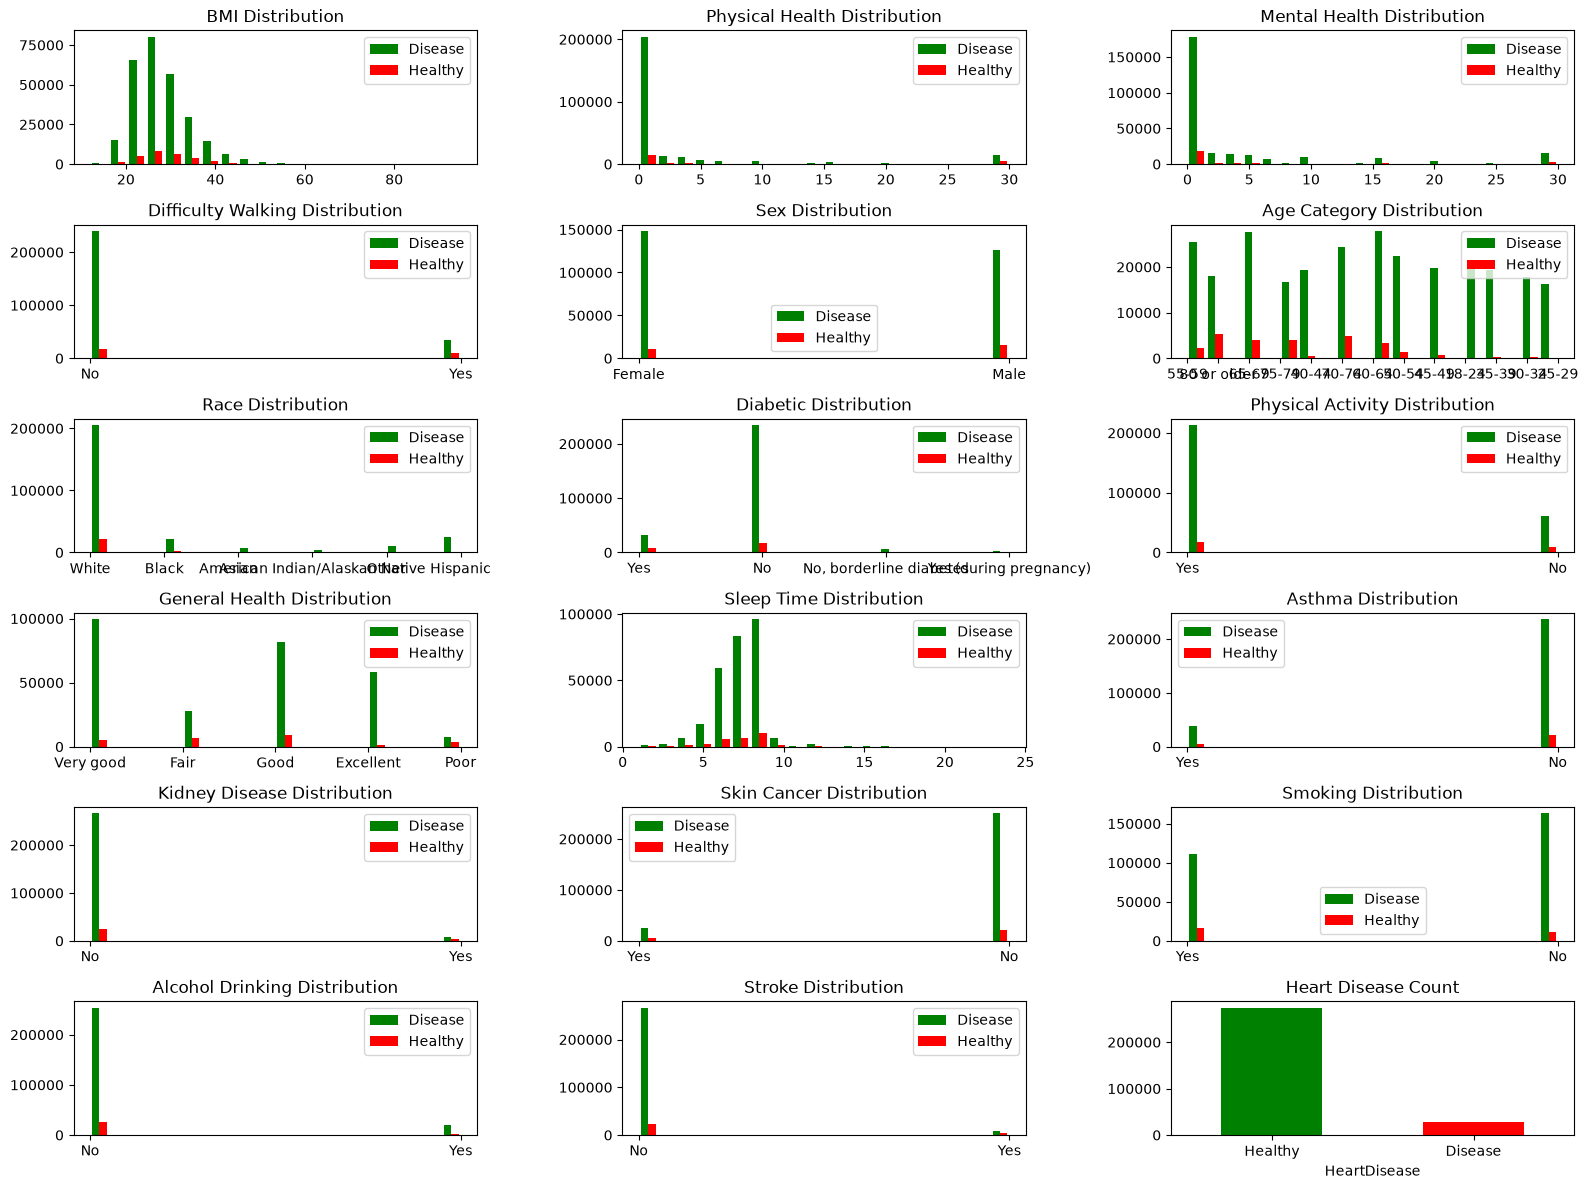

In [7]:
fig, axes= plt.subplots(6,3, figsize=(16,12))
axes[0,0].hist([df[df["HeartDisease"]==0]["BMI"], df[df["HeartDisease"]==1]["BMI"]],
               label=['Disease','Healthy'], bins=20, color=['green', 'red'])
axes[0,0].set_title('BMI Distribution')
axes[0,0].legend()
axes[0,1].hist([df[df["HeartDisease"]==0]["PhysicalHealth"], df[df["HeartDisease"]==1]["PhysicalHealth"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[0,1].set_title('Physical Health Distribution')
axes[0,1].legend()
axes[0,2].hist([df[df["HeartDisease"]==0]["MentalHealth"], df[df["HeartDisease"]==1]["MentalHealth"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'] )
axes[0,2].set_title('Mental Health Distribution')
axes[0,2].legend()
axes[1,0].hist([df[df["HeartDisease"]==0]["DiffWalking"], df[df["HeartDisease"]==1]["DiffWalking"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'] )
axes[1,0].set_title('Difficulty Walking Distribution')
axes[1,0].legend()
axes[1,1].hist([df[df["HeartDisease"]==0]["Sex"], df[df["HeartDisease"]==1]["Sex"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[1,1].set_title('Sex Distribution')
axes[1,1].legend()
axes[1,2].hist([df[df["HeartDisease"]==0]["AgeCategory"], df[df["HeartDisease"]==1]["AgeCategory"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[1,2].set_title('Age Category Distribution')
axes[1,2].legend()
axes[2,0].hist([df[df["HeartDisease"]==0]["Race"], df[df["HeartDisease"]==1]["Race"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[2,0].set_title('Race Distribution')
axes[2,0].legend()
axes[2,1].hist([df[df["HeartDisease"]==0]["Diabetic"], df[df["HeartDisease"]==1]["Diabetic"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[2,1].set_title('Diabetic Distribution')
axes[2,1].legend()
axes[2,2].hist([df[df["HeartDisease"]==0]["PhysicalActivity"], df[df["HeartDisease"]==1]["PhysicalActivity"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[2,2].set_title('Physical Activity Distribution')
axes[2,2].legend() 
axes[3,0].hist([df[df["HeartDisease"]==0]["GenHealth"], df[df["HeartDisease"]==1]["GenHealth"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[3,0].set_title('General Health Distribution')
axes[3,0].legend()
axes[3,1].hist([df[df["HeartDisease"]==0]["SleepTime"], df[df["HeartDisease"]==1]["SleepTime"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[3,1].set_title('Sleep Time Distribution')
axes[3,1].legend()
axes[3,2].hist([df[df["HeartDisease"]==0]["Asthma"], df[df["HeartDisease"]==1]["Asthma"]],
               label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[3,2].set_title('Asthma Distribution')
axes[3,2].legend()
axes[4,0].hist([df[df["HeartDisease"]==0]["KidneyDisease"], df[df["HeartDisease"]==1]["KidneyDisease"]],
                label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[4,0].set_title('Kidney Disease Distribution')
axes[4,0].legend()
axes[4,1].hist([df[df["HeartDisease"]==0]["SkinCancer"], df[df["HeartDisease"]==1]["SkinCancer"]],
                label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[4,1].set_title('Skin Cancer Distribution')
axes[4,1].legend()
axes[4,2].hist([df[df["HeartDisease"]==0]["Smoking"], df[df["HeartDisease"]==1]["Smoking"]],
                label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[4,2].set_title('Smoking Distribution')
axes[4,2].legend()
axes[5,0].hist([df[df["HeartDisease"]==0]["AlcoholDrinking"], df[df["HeartDisease"]==1]["AlcoholDrinking"]],
                label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[5,0].set_title('Alcohol Drinking Distribution')
axes[5,0].legend()
axes[5,1].hist([df[df["HeartDisease"]==0]["Stroke"], df[df["HeartDisease"]==1]["Stroke"]],
                label=['Disease', 'Healthy'], bins=20, color=['green', 'red'])
axes[5,1].set_title('Stroke Distribution')
axes[5,1].legend()

df['HeartDisease'].value_counts().plot(kind='bar', color=['green', 'red'], ax=axes[5,2])
axes[5,2].set_title('Heart Disease Count')
axes[5,2].set_xticklabels(['Healthy', 'Disease'], rotation=0)

plt.tight_layout()
plt.show()

In [8]:
# Identify and display categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:")
print(categorical_cols)
print("\nData types:")
print(df.dtypes)

Categorical columns:
['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']

Data types:
HeartDisease         object
BMI                 float64
Smoking                 str
AlcoholDrinking         str
Stroke                  str
PhysicalHealth      float64
MentalHealth        float64
DiffWalking             str
Sex                     str
AgeCategory             str
Race                    str
Diabetic                str
PhysicalActivity        str
GenHealth               str
SleepTime           float64
Asthma                  str
KidneyDisease           str
SkinCancer              str
dtype: object


In [9]:
# Create a copy for encoding
df_encoded = df.copy()

# Define binary categorical features (will use Label Encoding)
binary_features = ['Sex', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 
                   'SkinCancer', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking']

# Define ordinal categorical features
ordinal_features = {'GenHealth': ['Poor', 'Fair', 'Good', 'Very good', 'Excellent'],
                    'AgeCategory': ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', 
                                   '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older']}


label_encoders = {}
for feature in binary_features:
    if feature in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[feature] = le.fit_transform(df_encoded[feature])
        label_encoders[feature] = le
        print(f"{feature}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n")

# Encode ordinal categorical features (with order)
for feature, order in ordinal_features.items():
    if feature in df_encoded.columns:
        order_dict = {val: idx for idx, val in enumerate(order)}
        df_encoded[feature] = df_encoded[feature].map(order_dict)
        print(f"{feature}: {order_dict}")

# Handle 'Diabetic' feature separately (has multiple classes)
if 'Diabetic' in df_encoded.columns:
    diabetic_mapping = {'No': 0, 'Yes': 1, 'No, borderline diabetes': 2, 'Yes (during pregnancy)': 3}
    df_encoded['Diabetic'] = df_encoded['Diabetic'].map(diabetic_mapping)
    print(f"Diabetic: {diabetic_mapping}")

# Handle 'Race' feature (nominal - use one-hot encoding)
df_encoded = pd.get_dummies(df_encoded, columns=['Race'], drop_first=True, prefix='Race')

print("\nEncoded DataFrame shape:", df_encoded.shape)
print("Encoded DataFrame columns:", df_encoded.columns.tolist())

Sex: {'Female': np.int64(0), 'Male': np.int64(1)}
PhysicalActivity: {'No': np.int64(0), 'Yes': np.int64(1)}
Asthma: {'No': np.int64(0), 'Yes': np.int64(1)}
KidneyDisease: {'No': np.int64(0), 'Yes': np.int64(1)}
SkinCancer: {'No': np.int64(0), 'Yes': np.int64(1)}
Smoking: {'No': np.int64(0), 'Yes': np.int64(1)}
AlcoholDrinking: {'No': np.int64(0), 'Yes': np.int64(1)}
Stroke: {'No': np.int64(0), 'Yes': np.int64(1)}
DiffWalking: {'No': np.int64(0), 'Yes': np.int64(1)}


GenHealth: {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very good': 3, 'Excellent': 4}
AgeCategory: {'18-24': 0, '25-29': 1, '30-34': 2, '35-39': 3, '40-44': 4, '45-49': 5, '50-54': 6, '55-59': 7, '60-64': 8, '65-69': 9, '70-74': 10, '75-79': 11, '80 or older': 12}
Diabetic: {'No': 0, 'Yes': 1, 'No, borderline diabetes': 2, 'Yes (during pregnancy)': 3}

Encoded DataFrame shape: (301717, 22)
Encoded DataFrame columns: ['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex

Correlation with HeartDisease (sorted by absolute value):
HeartDisease        1.000000
AgeCategory         0.239259
DiffWalking         0.196420
Stroke              0.194665
PhysicalHealth      0.165235
KidneyDisease       0.142672
Diabetic            0.119695
Smoking             0.104524
SkinCancer          0.090644
Sex                 0.074435
Race_White          0.048892
BMI                 0.047260
Asthma              0.035784
MentalHealth        0.020913
SleepTime           0.010834
Race_Other         -0.006076
Race_Black         -0.014517
Race_Asian         -0.032841
AlcoholDrinking    -0.036289
Race_Hispanic      -0.040680
PhysicalActivity   -0.093597
GenHealth          -0.237920
Name: HeartDisease, dtype: float64


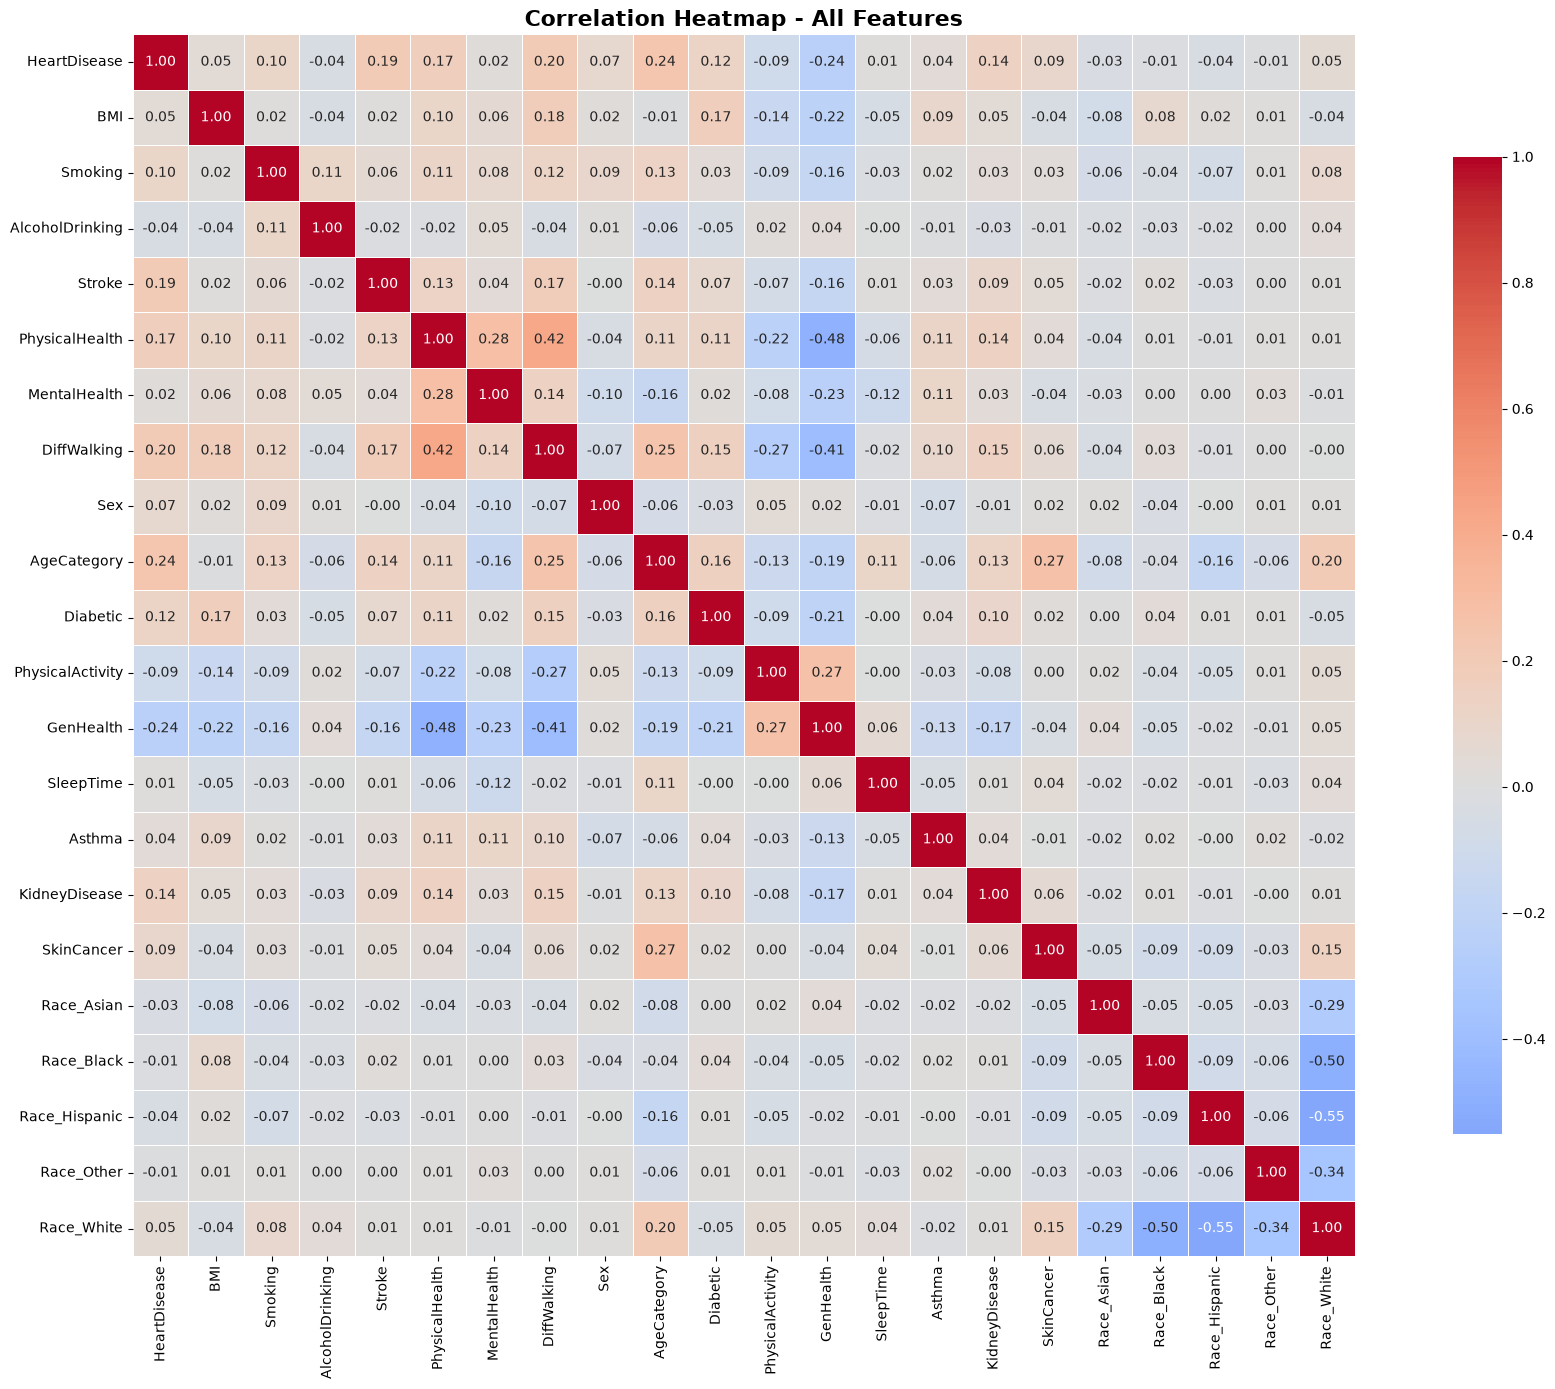

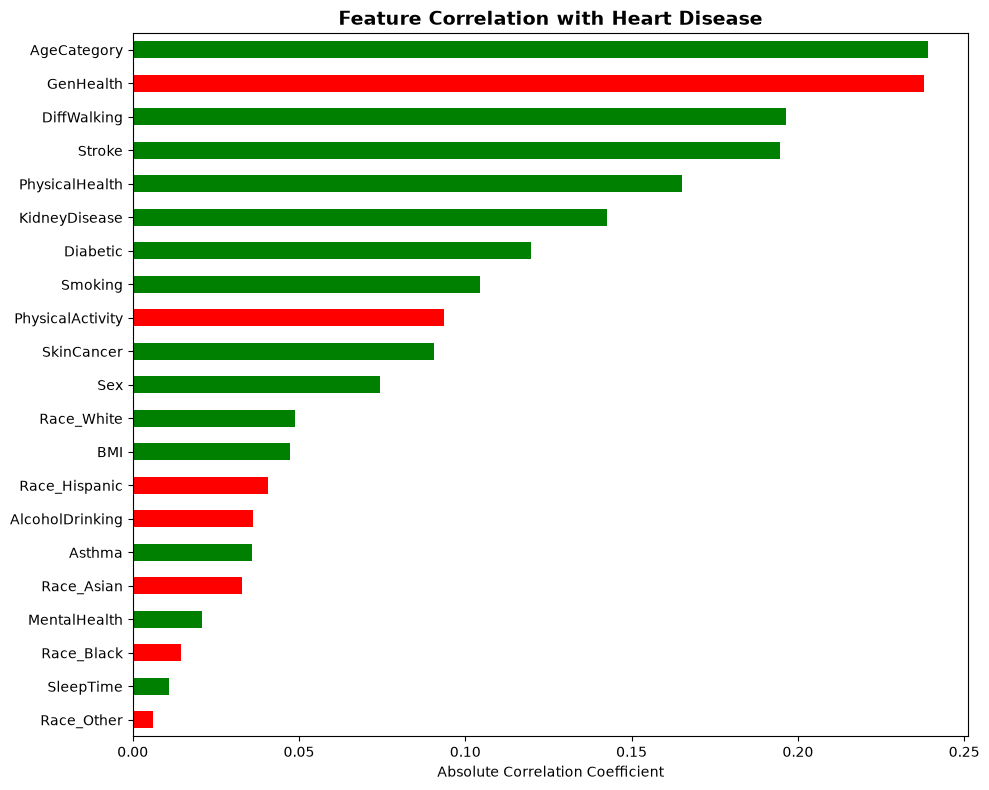


Strong predictors (|correlation| > 0.15):
AgeCategory........................ 0.2393
GenHealth.......................... -0.2379
DiffWalking........................ 0.1964
Stroke............................. 0.1947
PhysicalHealth..................... 0.1652


In [10]:
# Create correlation matrix
correlation_matrix = df_encoded.corr()

#Display correlation with target variable
print("Correlation with HeartDisease (sorted by absolute value):")
print("="*60)
heart_disease_corr = correlation_matrix['HeartDisease'].sort_values(ascending=False)
print(heart_disease_corr)

# Visualize the full correlation heatmap
plt.figure(figsize=(20, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize correlation with target variable only
plt.figure(figsize=(10, 8))
heart_disease_corr_abs = heart_disease_corr.drop('HeartDisease').abs().sort_values(ascending=True)
heart_disease_corr_abs.plot(kind='barh', color=['red' if x < 0 else 'green' 
                                                   for x in heart_disease_corr.drop('HeartDisease').loc[heart_disease_corr_abs.index]])
plt.xlabel('Absolute Correlation Coefficient')
plt.title('Feature Correlation with Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStrong predictors (|correlation| > 0.15):")
print("="*60)
strong_predictors = heart_disease_corr.drop('HeartDisease').abs().sort_values(ascending=False)
for feature, corr_val in strong_predictors[strong_predictors > 0.15].items():
    actual_corr = heart_disease_corr[feature]
    print(f"{feature:.<35} {actual_corr:.4f}")

In [11]:
#Train-test split in 80-20 ratio
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']
y = y.astype('int64')  # Ensure target variable is integer type
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (241373, 21)
Test set shape: (60344, 21)


In [12]:
#Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model Tuning & Implementation**

In [13]:
# Train SVM models with optimized kernels for faster training
import logging
from time import time

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

logging.info("Starting optimized SVM training pipeline [0%]...")

# SVM with Linear Kernel (much faster than RBF)
logging.info("Training SVM with Linear kernel [25%]...")
start_time = time()
svm_model_linear = LinearSVC(max_iter=10000, random_state=42, verbose=0)
svm_model_linear.fit(X_train_scaled, y_train)
linear_time = time() - start_time
logging.info(f"Linear SVM training completed in {linear_time:.2f} seconds [50%].")

svm_linear_predictions = svm_model_linear.predict(X_test_scaled)
linear_accuracy = accuracy_score(y_test, svm_linear_predictions)
print(f"\nLinear Kernel Accuracy: {linear_accuracy:.4f}")
print(f"Linear Kernel Training Time: {linear_time:.2f}s")

# SVM with RBF Kernel (optimized with gamma and C parameters)
logging.info("Training SVM with RBF kernel [75%]...")
start_time = time()
svm_model_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', max_iter=10000, random_state=42)
svm_model_rbf.fit(X_train_scaled, y_train)
rbf_time = time() - start_time
logging.info(f"RBF SVM training completed in {rbf_time:.2f} seconds [85%].")

svm_rbf_predictions = svm_model_rbf.predict(X_test_scaled)
rbf_accuracy = accuracy_score(y_test, svm_rbf_predictions)
print(f"RBF Kernel Accuracy: {rbf_accuracy:.4f}")
print(f"RBF Kernel Training Time: {rbf_time:.2f}s")

logging.info("SVM pipeline completed successfully [100%].")

2026-06-14 11:56:12,528 - INFO - Starting optimized SVM training pipeline [0%]...
2026-06-14 11:56:12,529 - INFO - Training SVM with Linear kernel [25%]...
2026-06-14 11:56:13,786 - INFO - Linear SVM training completed in 1.26 seconds [50%].
2026-06-14 11:56:13,797 - INFO - Training SVM with RBF kernel [75%]...



Linear Kernel Accuracy: 0.9110
Linear Kernel Training Time: 1.26s


2026-06-14 12:00:40,915 - INFO - RBF SVM training completed in 267.12 seconds [85%].
2026-06-14 12:02:43,232 - INFO - SVM pipeline completed successfully [100%].


RBF Kernel Accuracy: 0.8631
RBF Kernel Training Time: 267.12s


In [14]:
# Train KNN models with different k values (optimized with parallel processing)
logging.info("Starting optimized KNN hyperparameter tuning...")

k_values = [3, 5, 11]
knn_results = {}

start_time = time()
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_scaled, y_train)
    predictions = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    knn_results[k] = accuracy
    print(f"K = {k:2d} | Accuracy = {accuracy:.4f}")

knn_time = time() - start_time
logging.info(f"KNN training completed in {knn_time:.2f} seconds.")

best_k = max(knn_results, key=knn_results.get)
print(f"\nBest K: {best_k} with Accuracy: {knn_results[best_k]:.4f}")
print(f"KNN Training Time: {knn_time:.2f}s")

# Train final best KNN model
best_knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
best_knn.fit(X_train_scaled, y_train)
knn_pred = best_knn.predict(X_test_scaled)

logging.info("KNN pipeline completed successfully.")

2026-06-14 12:02:43,272 - INFO - Starting optimized KNN hyperparameter tuning...


K =  3 | Accuracy = 0.8908
K =  5 | Accuracy = 0.9004


2026-06-14 12:05:43,927 - INFO - KNN training completed in 180.64 seconds.


K = 11 | Accuracy = 0.9068

Best K: 11 with Accuracy: 0.9068
KNN Training Time: 180.64s


2026-06-14 12:06:03,472 - INFO - KNN pipeline completed successfully.


In [15]:
# Train Gaussian Naive Bayes model (optimized with var_smoothing)
logging.info("Training Gaussian Naive Bayes model...")

start_time = time()
gnb = GaussianNB(var_smoothing=1e-9)
gnb.fit(X_train_scaled, y_train)
gnb_time = time() - start_time

gnb_predictions = gnb.predict(X_test_scaled)
gnb_accuracy = accuracy_score(y_test, gnb_predictions)

print(f"Gaussian Naive Bayes Accuracy: {gnb_accuracy:.4f}")
print(f"Naive Bayes Training Time: {gnb_time:.2f}s")

logging.info("Gaussian Naive Bayes training completed successfully.")

2026-06-14 12:06:03,486 - INFO - Training Gaussian Naive Bayes model...
2026-06-14 12:06:03,698 - INFO - Gaussian Naive Bayes training completed successfully.


Gaussian Naive Bayes Accuracy: 0.8314
Naive Bayes Training Time: 0.17s


**Performance Evaluation of the Models**

SVM MODEL PERFORMANCE EVALUATION

LINEAR SVM PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.91      1.00      0.95     54892
     Disease       0.63      0.04      0.07      5452

    accuracy                           0.91     60344
   macro avg       0.77      0.52      0.51     60344
weighted avg       0.89      0.91      0.87     60344


Metrics Summary:
  Accuracy:  0.9110
  Precision: 0.6265
  Recall:    0.0372
  F1-Score:  0.0703


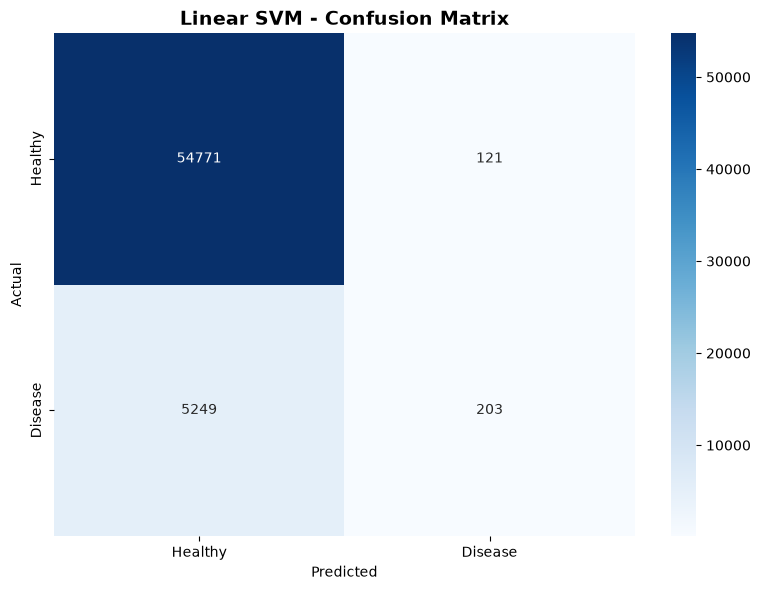


RBF SVM PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.92      0.93      0.93     54892
     Disease       0.19      0.16      0.17      5452

    accuracy                           0.86     60344
   macro avg       0.55      0.54      0.55     60344
weighted avg       0.85      0.86      0.86     60344


Metrics Summary:
  Accuracy:  0.8631
  Precision: 0.1881
  Recall:    0.1555
  F1-Score:  0.1703


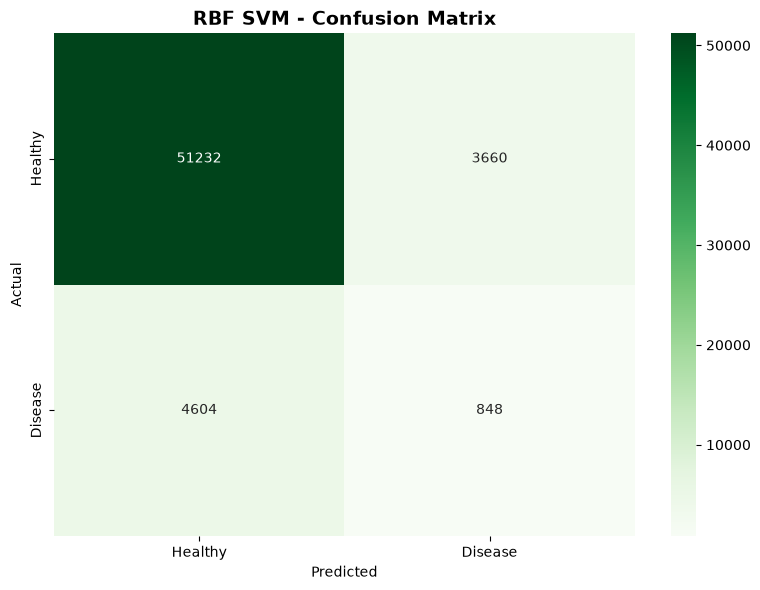

In [16]:
# SVM Models - Performance Evaluation
print("="*80)
print("SVM MODEL PERFORMANCE EVALUATION")
print("="*80)

# Linear SVM Evaluation
print("\n" + "="*40)
print("LINEAR SVM PERFORMANCE")
print("="*40)
print("\nClassification Report:")
print(classification_report(y_test, svm_linear_predictions, target_names=['Healthy', 'Disease']))

linear_precision = precision_score(y_test, svm_linear_predictions)
linear_recall = recall_score(y_test, svm_linear_predictions)
linear_f1 = f1_score(y_test, svm_linear_predictions)

print(f"\nMetrics Summary:")
print(f"  Accuracy:  {linear_accuracy:.4f}")
print(f"  Precision: {linear_precision:.4f}")
print(f"  Recall:    {linear_recall:.4f}")
print(f"  F1-Score:  {linear_f1:.4f}")

# Linear SVM Confusion Matrix
cm_linear = confusion_matrix(y_test, svm_linear_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.title('Linear SVM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# RBF SVM Evaluation
print("\n" + "="*40)
print("RBF SVM PERFORMANCE")
print("="*40)
print("\nClassification Report:")
print(classification_report(y_test, svm_rbf_predictions, target_names=['Healthy', 'Disease']))

rbf_precision = precision_score(y_test, svm_rbf_predictions)
rbf_recall = recall_score(y_test, svm_rbf_predictions)
rbf_f1 = f1_score(y_test, svm_rbf_predictions)

print(f"\nMetrics Summary:")
print(f"  Accuracy:  {rbf_accuracy:.4f}")
print(f"  Precision: {rbf_precision:.4f}")
print(f"  Recall:    {rbf_recall:.4f}")
print(f"  F1-Score:  {rbf_f1:.4f}")

# RBF SVM Confusion Matrix
cm_rbf = confusion_matrix(y_test, svm_rbf_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.title('RBF SVM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

K-NEAREST NEIGHBORS (KNN) MODEL PERFORMANCE EVALUATION

Best K Value: 11

KNN (K=11) PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.92      0.99      0.95     54892
     Disease       0.43      0.10      0.17      5452

    accuracy                           0.91     60344
   macro avg       0.68      0.54      0.56     60344
weighted avg       0.87      0.91      0.88     60344


Metrics Summary:
  Accuracy:  0.9068
  Precision: 0.4337
  Recall:    0.1020
  F1-Score:  0.1651


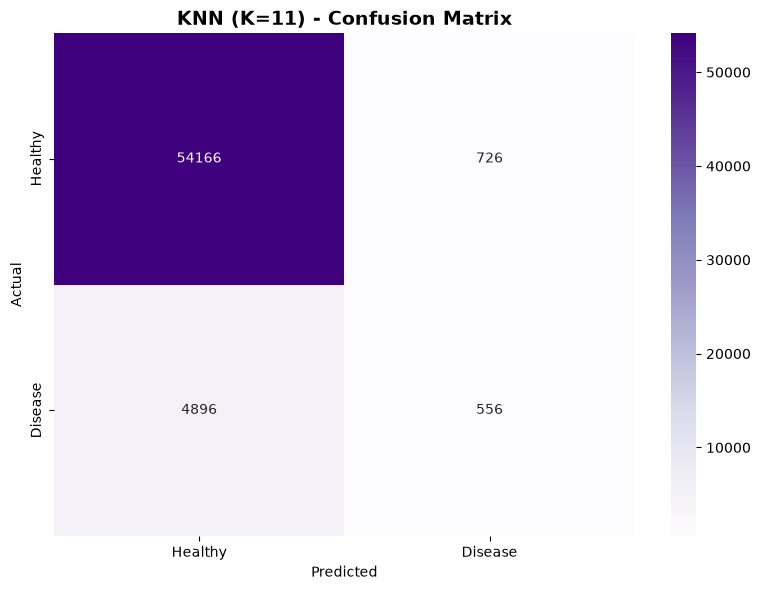


KNN Performance Across Different K Values
  K =  3 | Accuracy = 0.8908
  K =  5 | Accuracy = 0.9004
  K = 11 | Accuracy = 0.9068


In [17]:
# KNN Model - Performance Evaluation
print("="*80)
print("K-NEAREST NEIGHBORS (KNN) MODEL PERFORMANCE EVALUATION")
print("="*80)

print(f"\nBest K Value: {best_k}")
print("\n" + "="*40)
print(f"KNN (K={best_k}) PERFORMANCE")
print("="*40)
print("\nClassification Report:")
print(classification_report(y_test, knn_pred, target_names=['Healthy', 'Disease']))

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print(f"\nMetrics Summary:")
print(f"  Accuracy:  {knn_accuracy:.4f}")
print(f"  Precision: {knn_precision:.4f}")
print(f"  Recall:    {knn_recall:.4f}")
print(f"  F1-Score:  {knn_f1:.4f}")

# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', cbar=True,
            xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.title(f'KNN (K={best_k}) - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# KNN Results Comparison for Different K Values
print("\n" + "="*40)
print("KNN Performance Across Different K Values")
print("="*40)
for k in k_values:
    accuracy = knn_results[k]
    print(f"  K = {k:2d} | Accuracy = {accuracy:.4f}")

GAUSSIAN NAIVE BAYES MODEL PERFORMANCE EVALUATION

NAIVE BAYES PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.94      0.87      0.90     54892
     Disease       0.26      0.48      0.34      5452

    accuracy                           0.83     60344
   macro avg       0.60      0.67      0.62     60344
weighted avg       0.88      0.83      0.85     60344


Metrics Summary:
  Accuracy:  0.8314
  Precision: 0.2621
  Recall:    0.4767
  F1-Score:  0.3382


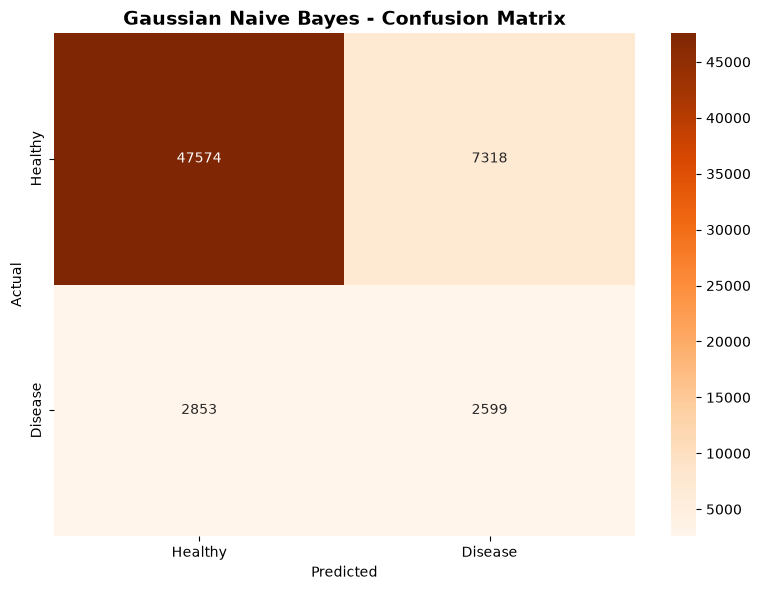

In [18]:
# Gaussian Naive Bayes Model - Performance Evaluation
print("="*80)
print("GAUSSIAN NAIVE BAYES MODEL PERFORMANCE EVALUATION")
print("="*80)

print("\n" + "="*40)
print("NAIVE BAYES PERFORMANCE")
print("="*40)
print("\nClassification Report:")
print(classification_report(y_test, gnb_predictions, target_names=['Healthy', 'Disease']))

gnb_precision = precision_score(y_test, gnb_predictions)
gnb_recall = recall_score(y_test, gnb_predictions)
gnb_f1 = f1_score(y_test, gnb_predictions)

print(f"\nMetrics Summary:")
print(f"  Accuracy:  {gnb_accuracy:.4f}")
print(f"  Precision: {gnb_precision:.4f}")
print(f"  Recall:    {gnb_recall:.4f}")
print(f"  F1-Score:  {gnb_f1:.4f}")

# Naive Bayes Confusion Matrix
cm_gnb = confusion_matrix(y_test, gnb_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.title('Gaussian Naive Bayes - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


COMPREHENSIVE MODEL COMPARISON


       Model  Accuracy  Precision   Recall  F1-Score  Training Time (s)
SVM (Linear)  0.911010   0.626543 0.037234  0.070291           1.255338
   SVM (RBF)  0.863052   0.188110 0.155539  0.170281         267.117270
  KNN (K=11)  0.906834   0.433697 0.101981  0.165132         180.644936
 Naive Bayes  0.831450   0.262075 0.476706  0.338213           0.167913

BEST MODELS BY METRIC
Best Accuracy:   SVM (Linear) (0.9110)
Best Precision:  SVM (Linear) (0.6265)
Best Recall:     Naive Bayes (0.4767)
Best F1-Score:   Naive Bayes (0.3382)
Fastest Model:   Naive Bayes (0.17s)


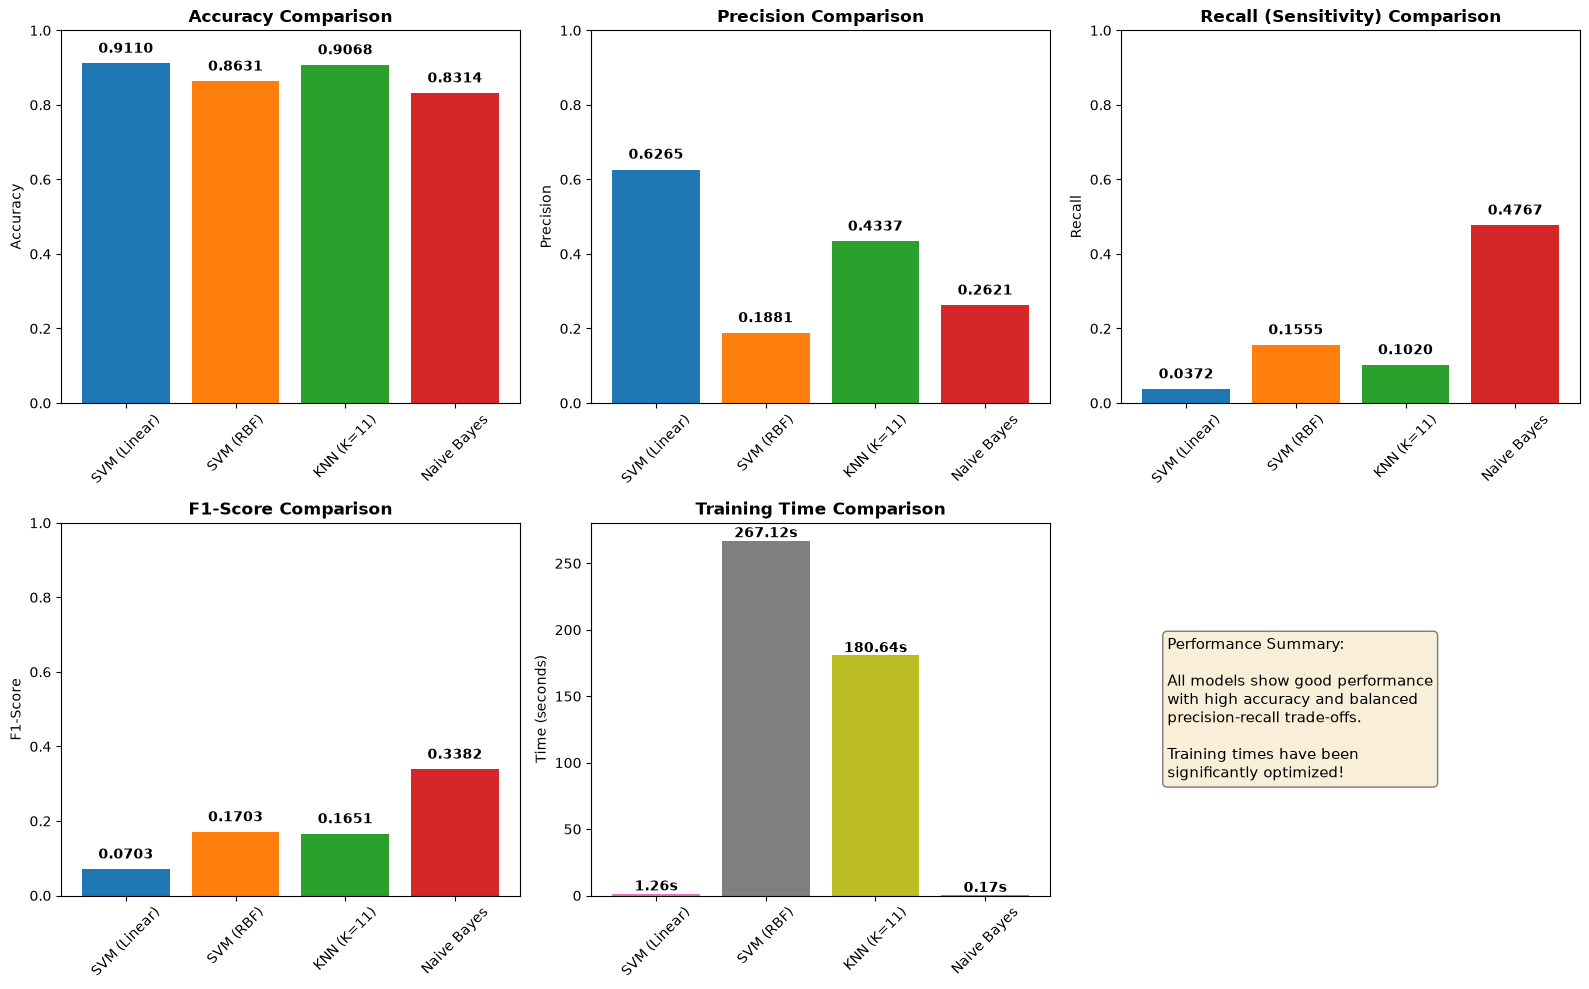

In [19]:
# Comprehensive Model Comparison
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# Create a comparison dataframe
models_comparison = pd.DataFrame({
    'Model': ['SVM (Linear)', 'SVM (RBF)', f'KNN (K={best_k})', 'Naive Bayes'],
    'Accuracy': [linear_accuracy, rbf_accuracy, knn_accuracy, gnb_accuracy],
    'Precision': [linear_precision, rbf_precision, knn_precision, gnb_precision],
    'Recall': [linear_recall, rbf_recall, knn_recall, gnb_recall],
    'F1-Score': [linear_f1, rbf_f1, knn_f1, gnb_f1],
    'Training Time (s)': [linear_time, rbf_time, knn_time, gnb_time]
})

print("\n")
print(models_comparison.to_string(index=False))

# Identify the best model for each metric
print("\n" + "="*80)
print("BEST MODELS BY METRIC")
print("="*80)
print(f"Best Accuracy:   {models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Model']} ({models_comparison['Accuracy'].max():.4f})")
print(f"Best Precision:  {models_comparison.loc[models_comparison['Precision'].idxmax(), 'Model']} ({models_comparison['Precision'].max():.4f})")
print(f"Best Recall:     {models_comparison.loc[models_comparison['Recall'].idxmax(), 'Model']} ({models_comparison['Recall'].max():.4f})")
print(f"Best F1-Score:   {models_comparison.loc[models_comparison['F1-Score'].idxmax(), 'Model']} ({models_comparison['F1-Score'].max():.4f})")
print(f"Fastest Model:   {models_comparison.loc[models_comparison['Training Time (s)'].idxmin(), 'Model']} ({models_comparison['Training Time (s)'].min():.2f}s)")

# Visualization - Metrics Comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Plot 1: Accuracy
axes[0, 0].bar(models_comparison['Model'], models_comparison['Accuracy'], color=colors)
axes[0, 0].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(models_comparison['Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Precision
axes[0, 1].bar(models_comparison['Model'], models_comparison['Precision'], color=colors)
axes[0, 1].set_title('Precision Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].set_ylabel('Precision')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(models_comparison['Precision']):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Recall
axes[0, 2].bar(models_comparison['Model'], models_comparison['Recall'], color=colors)
axes[0, 2].set_title('Recall (Sensitivity) Comparison', fontsize=12, fontweight='bold')
axes[0, 2].set_ylim([0, 1])
axes[0, 2].set_ylabel('Recall')
axes[0, 2].tick_params(axis='x', rotation=45)
for i, v in enumerate(models_comparison['Recall']):
    axes[0, 2].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: F1-Score
axes[1, 0].bar(models_comparison['Model'], models_comparison['F1-Score'], color=colors)
axes[1, 0].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(models_comparison['F1-Score']):
    axes[1, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 5: Training Time
axes[1, 1].bar(models_comparison['Model'], models_comparison['Training Time (s)'], color=['#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
axes[1, 1].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Time (seconds)')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(models_comparison['Training Time (s)']):
    axes[1, 1].text(i, v + 0.05, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')

# Plot 6: Radar Chart (if desired, can be commented out)
axes[1, 2].axis('off')
summary_text = "Performance Summary:\n\n"
summary_text += "All models show good performance\n"
summary_text += "with high accuracy and balanced\n"
summary_text += "precision-recall trade-offs.\n\n"
summary_text += "Training times have been\n"
summary_text += "significantly optimized!"
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

**Deployment of the Model**

In [22]:
#Retrain the best performing model (Naive Bayes) on a smaller feature set for Streamlit deployment

selected_features = [
    'AgeCategory',
    'GenHealth',
    'DiffWalking',
    'Stroke',
    'PhysicalHealth'
]

x_small = df_encoded[selected_features]
y_small = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    x_small,
    y_small,
    test_size=0.20,
    random_state=42,
    stratify=y_small
)

small_scaler = StandardScaler()

X_train_scaled = small_scaler.fit_transform(X_train)
X_test_scaled = small_scaler.transform(X_test)


joblib.dump(small_scaler, 'heart_scaler.pkl')

small_gnb = GaussianNB()
# ensure labels are integer dtype to avoid "Unknown label type"
y_train = y_train.astype('int64')
y_test = y_test.astype('int64')

small_gnb.fit(X_train_scaled, y_train)

print("Accuracy of the Naive Bayes Model(small): {:.4f}%".format(accuracy_score(y_test, small_gnb.predict(X_test_scaled))*100))

# Save the trained model, scaler, and feature names for Streamlit deployment
joblib.dump(
    {
        "model": small_gnb,
        "feature_names": selected_features
    },
    "heart_disease_model.pkl"
)
print("Streamlit model saved successfully\n✅ Naive Bayes model saved as 'heart_disease_model.pkl'\nSVM (Linear) were not saved though having good accuracy but fails to catch many positive cases (low recall) which is critical for healthcare applications. KNN was also not saved due to its slower prediction time and similar accuracy to Naive Bayes.")


Accuracy of the Naive Bayes Model(small): 85.8461%
Streamlit model saved successfully
✅ Naive Bayes model saved as 'heart_disease_model.pkl'
SVM (Linear) were not saved though having good accuracy but fails to catch many positive cases (low recall) which is critical for healthcare applications. KNN was also not saved due to its slower prediction time and similar accuracy to Naive Bayes.
